In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.arima.model import ARIMA
import itertools

In [110]:
%pip install openpyxl
%pip install mlxtend
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\argparse-1.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\astor-0.8.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\pyggi-2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run:

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\argparse-1.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\astor-0.8.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\pyggi-2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run:

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.6 MB 2.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.6 MB 1.6 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.6 MB 2.1 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.6 MB 2.2 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.6 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.6 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.5 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.6 MB 2.6 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 2.7 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.6 MB 2.7 MB/s eta 0:00:02
   -----------------------

DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\argparse-1.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\astor-0.8.1-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\rayantech\programs\python\python312\lib\site-packages\pyggi-2.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run:

In [3]:
df = pd.read_excel("Online Retail.xlsx")
print(df.head)
print(df.shape)
print(df.info())

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Custom

Handle Missing Values

In [4]:
print("Before removing missing values:\n", df.isna().sum())

Before removing missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
df = df[df["Description"].notna() & (df["Description"] != "")]
print("After removing missing values:\n", df.isna().sum())

After removing missing values:
 InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64


Remove invalid records

In [6]:
bad_cnt = df[(df["Quantity"] <= 0)].shape[0]
print("Rows with zero or negative quantity BEFORE:", bad_cnt)

df_clean = df[df["Quantity"] > 0]
after_cnt = df_clean[(df_clean["Quantity"] <= 0)].shape[0]
print("Rows with zero or negative quantity AFTER:", after_cnt)

Rows with zero or negative quantity BEFORE: 9762
Rows with zero or negative quantity AFTER: 0


In [7]:
bad_cnt = df[(df["UnitPrice"] <= 0)].shape[0]
print("Rows with zero or negative UnitPrice BEFORE:", bad_cnt)

df_clean = df[df["UnitPrice"] > 0]
after_cnt = df_clean[(df_clean["UnitPrice"] <= 0)].shape[0]
print("Rows with zero or negative quantity AFTER:", after_cnt)

Rows with zero or negative UnitPrice BEFORE: 1063
Rows with zero or negative quantity AFTER: 0


Data type conversion

In [8]:
print("BEFORE: ", df["InvoiceDate"].dtype)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("AFTER: ", df["InvoiceDate"].dtype)

BEFORE:  datetime64[ns]
AFTER:  datetime64[ns]


Feature engineering

In [9]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
print(df["Quantity"].head, df["UnitPrice"].head, df["TotalAmount"].head)

<bound method NDFrame.head of 0          6
1          6
2          8
3          6
4          6
          ..
541904    12
541905     6
541906     4
541907     4
541908     3
Name: Quantity, Length: 540455, dtype: int64> <bound method NDFrame.head of 0         2.55
1         3.39
2         2.75
3         3.39
4         3.39
          ... 
541904    0.85
541905    2.10
541906    4.15
541907    4.15
541908    4.95
Name: UnitPrice, Length: 540455, dtype: float64> <bound method NDFrame.head of 0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalAmount, Length: 540455, dtype: float64>


In [10]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [11]:
original_count = df.shape[0]
df_grouped = df.groupby(["InvoiceNo", "Description"], as_index=False)["Quantity"].sum()

new_count = df_grouped.shape[0]
print("Before:", original_count)
print("After:", new_count)

print(df_grouped.columns)

Before: 531167
After: 520448
Index(['InvoiceNo', 'Description', 'Quantity'], dtype='object')


In [12]:
product_counts = df_grouped["Description"].value_counts()
frequent_products = product_counts[product_counts >= 10].index
df_filtered = df_grouped[df_grouped["Description"].isin(frequent_products)]
print(df_filtered["Description"].value_counts().min())

10


Preprocessing for Association Rule Mining

In [13]:
baskets = df_grouped.groupby("InvoiceNo")["Description"].apply(list).reset_index()
print(baskets.head)

<bound method NDFrame.head of       InvoiceNo                                        Description
0        536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...
1        536366  [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...
2        536367  [ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSOR...
3        536368  [BLUE COAT RACK PARIS FASHION, JAM MAKING SET ...
4        536369                         [BATH BUILDING BLOCK WORD]
...         ...                                                ...
20605    581586  [DOORMAT RED RETROSPOT, LARGE CAKE STAND  HANG...
20606    581587  [ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...
20607   A563185                                  [Adjust bad debt]
20608   A563186                                  [Adjust bad debt]
20609   A563187                                  [Adjust bad debt]

[20610 rows x 2 columns]>


Preprocessing for Time Series Analysis

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'InvoiceDay'],
      dtype='object')


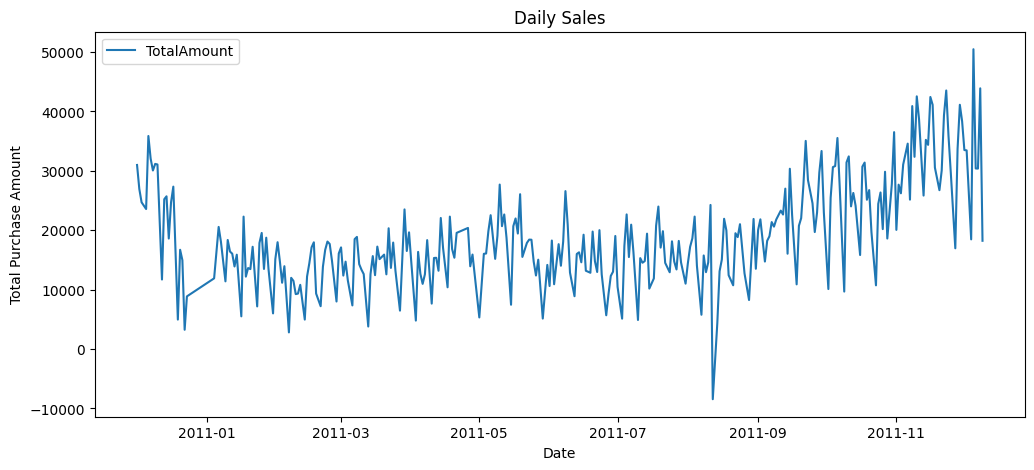

In [124]:
print(df.columns)

df["InvoiceDay"] = df["InvoiceDate"].dt.date
daily_sales = df.groupby("InvoiceDay")["TotalAmount"].sum().reset_index()
daily_sales.columns = ["Date", "TotalAmount"]
daily_sales = daily_sales.sort_values("Date")

daily_sales.plot(x="Date", y="TotalAmount", kind="line", figsize=(12,5))
plt.ylabel("Total Purchase Amount")
plt.title("Daily Sales")
plt.show()

Exploratory Data Analysis (EDA)

General Dataset Exploration 

            Quantity                    InvoiceDate      UnitPrice  \
count  531167.000000                         531167  531167.000000   
mean       10.293623  2011-07-04 19:55:25.199757824       3.858153   
min     -9600.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 12:13:00       1.250000   
50%         3.000000            2011-07-20 12:45:00       2.080000   
75%        10.000000            2011-10-19 12:54:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   13541.330000   
std       159.301358                            NaN      41.814651   

          CustomerID    TotalAmount  
count  397924.000000  531167.000000  
mean    15294.315171      20.039951  
min     12346.000000  -11062.060000  
25%     13969.000000       3.750000  
50%     15159.000000       9.900000  
75%     16795.000000      17.700000  
max     18287.000000  168469.600000  
std      1713.169877     270.942296   Index(['InvoiceNo', 'StockC

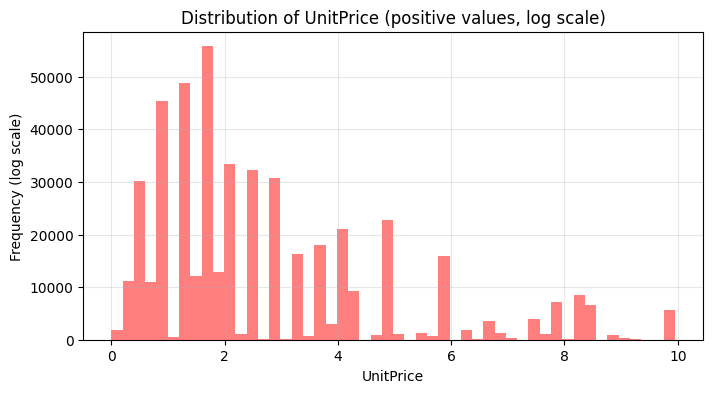

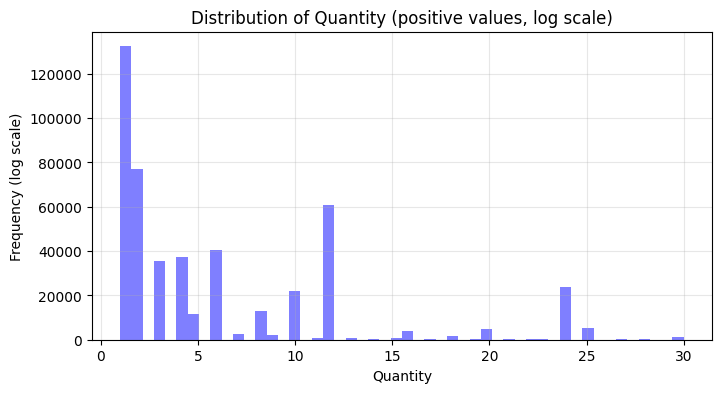

Description
WHITE HANGING HEART T-LIGHT HOLDER    1976
JUMBO BAG RED RETROSPOT               1873
LUNCH BAG RED RETROSPOT               1503
PARTY BUNTING                         1348
LUNCH BAG  BLACK SKULL.               1289
PACK OF 72 RETROSPOT CAKE CASES       1244
ASSORTED COLOUR BIRD ORNAMENT         1238
NATURAL SLATE HEART CHALKBOARD        1226
LUNCH BAG SPACEBOY DESIGN             1152
SET OF 3 CAKE TINS PANTRY DESIGN      1151
JUMBO BAG PINK POLKADOT               1141
LUNCH BAG CARS BLUE                   1140
JUMBO SHOPPER VINTAGE RED PAISLEY     1134
JUMBO STORAGE BAG SUKI                1128
HEART OF WICKER SMALL                 1127
Name: count, dtype: int64


C:\Users\RayanTech\AppData\Local\Temp\ipykernel_4120\3359277287.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")


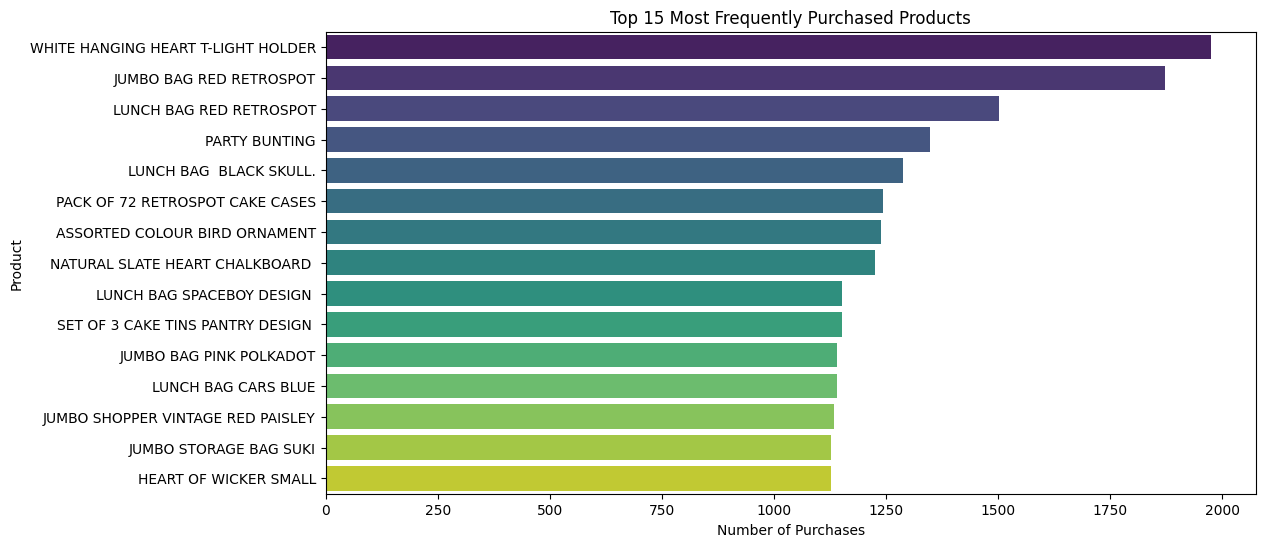

C:\Users\RayanTech\AppData\Local\Temp\ipykernel_4120\3359277287.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")


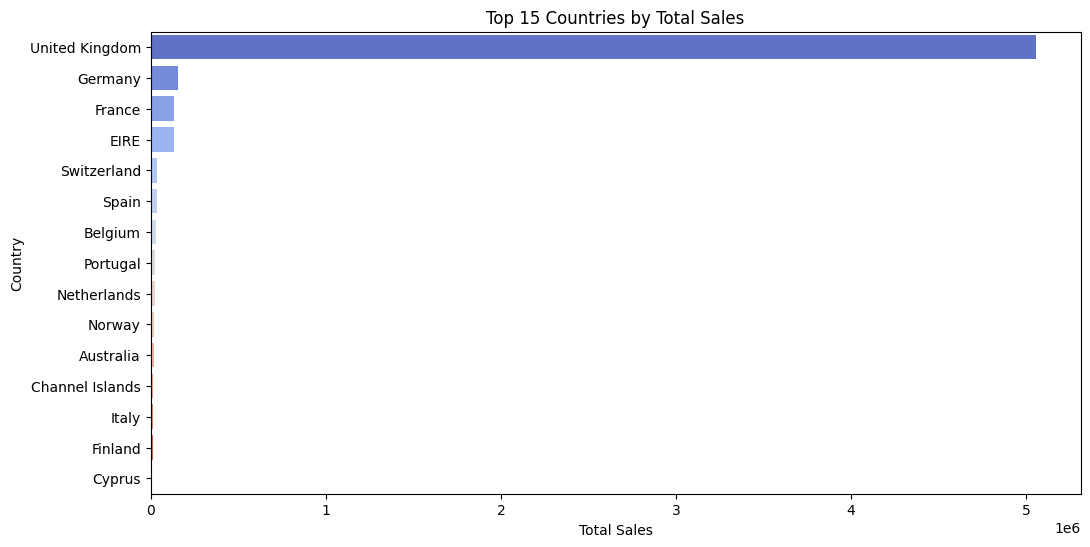

In [15]:
print(df.describe(), df.columns)

price_95 = df["UnitPrice"].quantile(0.95)
quantity_95 = df["Quantity"].quantile(0.95)
df = df[(df["UnitPrice"] <= price_95) & (df["Quantity"] <= quantity_95)]
df_filtered = df[(df["Quantity"] > 0) & 
                 (df["UnitPrice"] > 0) & 
                 (df["UnitPrice"] <= price_95) & 
                 (df["Quantity"] <= quantity_95)]
plt.figure(figsize=(8, 4))
plt.hist(df_filtered["UnitPrice"], bins=50, alpha=0.5, color='red')
plt.xlabel("UnitPrice")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of UnitPrice (positive values, log scale)")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_filtered["Quantity"], bins=50, alpha=0.5, color='blue')
plt.xlabel("Quantity")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Quantity (positive values, log scale)")
plt.grid(alpha=0.3)
plt.show()

top_products = df["Description"].value_counts().head(15)
print(top_products)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 15 Most Frequently Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.show()

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=country_sales.values, y=country_sales.index, palette="coolwarm")
plt.title("Top 15 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.show()

EDA for Association Rules 

      InvoiceNo                                        Description
0        536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...
1        536366  [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...
2        536367  [ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSOR...
3        536368  [BLUE COAT RACK PARIS FASHION, JAM MAKING SET ...
4        536369                         [BATH BUILDING BLOCK WORD]
...         ...                                                ...
20605    581586  [DOORMAT RED RETROSPOT, LARGE CAKE STAND  HANG...
20606    581587  [ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...
20607   A563185                                  [Adjust bad debt]
20608   A563186                                  [Adjust bad debt]
20609   A563187                                  [Adjust bad debt]

[20610 rows x 2 columns]
  InvoiceNo                                        Description  NumProducts
0    536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...            7
1    536366  [HAND

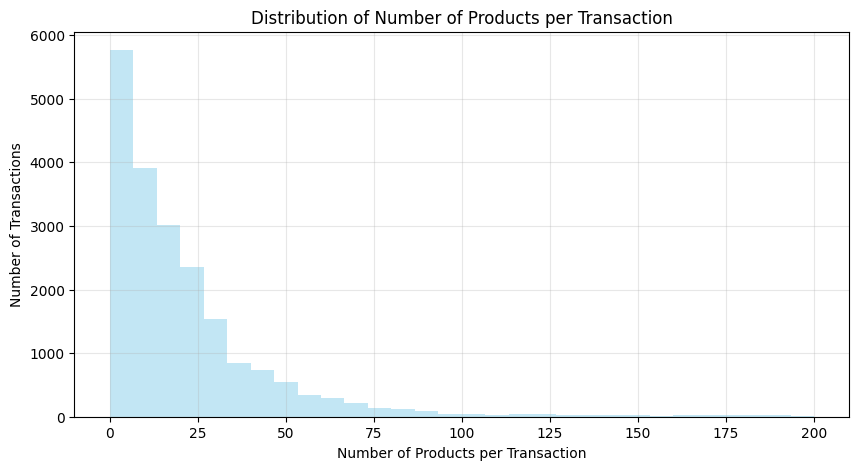

Mean products per transaction: 25.252207666181466
Median products per transaction: 15.0
Max products per transaction: 1108


In [16]:
print(baskets)
baskets["NumProducts"] = baskets["Description"].apply(len)
print(baskets.head())

plt.figure(figsize=(10,5))
plt.hist(baskets["NumProducts"], bins=30, range=(0, 200), color="skyblue", alpha=0.5)
plt.xlabel("Number of Products per Transaction")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Number of Products per Transaction")
plt.grid(alpha=0.3)
plt.show()

print("Mean products per transaction:", baskets["NumProducts"].mean())
print("Median products per transaction:", baskets["NumProducts"].median())
print("Max products per transaction:", baskets["NumProducts"].max())

      InvoiceNo                                        Description  \
0        536365  [CREAM CUPID HEARTS COAT HANGER, GLASS STAR FR...   
1        536366  [HAND WARMER RED POLKA DOT, HAND WARMER UNION ...   
2        536367  [ASSORTED COLOUR BIRD ORNAMENT, BOX OF 6 ASSOR...   
3        536368  [BLUE COAT RACK PARIS FASHION, JAM MAKING SET ...   
4        536369                         [BATH BUILDING BLOCK WORD]   
...         ...                                                ...   
20605    581586  [DOORMAT RED RETROSPOT, LARGE CAKE STAND  HANG...   
20606    581587  [ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...   
20607   A563185                                  [Adjust bad debt]   
20608   A563186                                  [Adjust bad debt]   
20609   A563187                                  [Adjust bad debt]   

       NumProducts  
0                7  
1                2  
2               12  
3                4  
4                1  
...            ...  
20605       

C:\Users\RayanTech\AppData\Local\Temp\ipykernel_4120\3291989156.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")


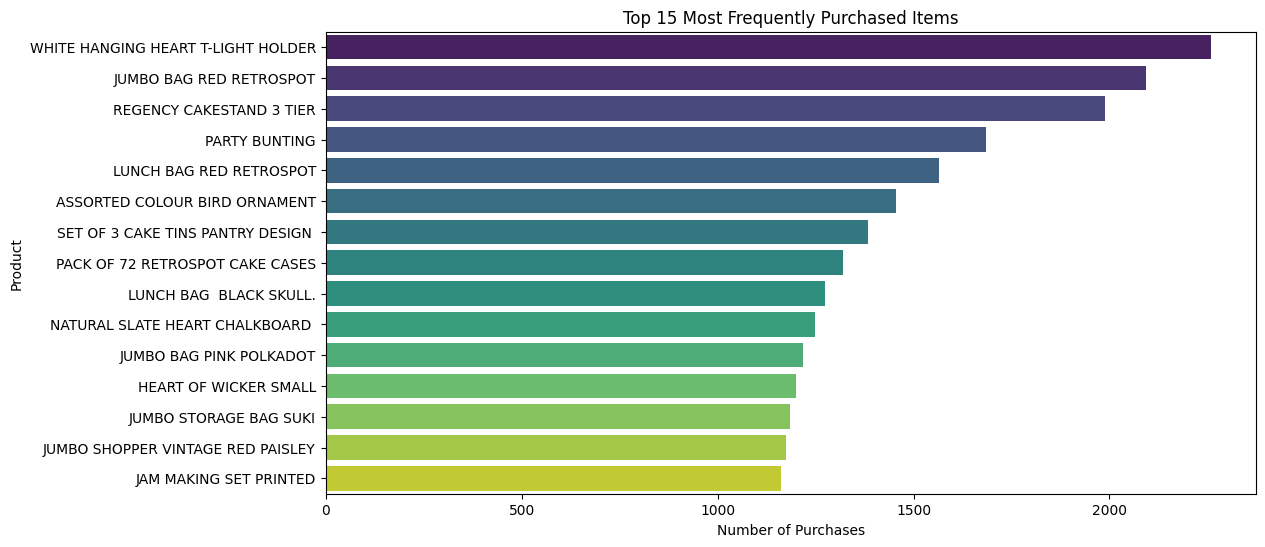

In [17]:
print(baskets)
all_items = baskets["Description"].explode()
item_counts = all_items.value_counts()
top_items = item_counts.head(15)
top_products = df["Description"].value_counts().head(15)

all_items = baskets["Description"].explode()
item_counts = all_items.value_counts() 
top_items = item_counts.head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top_items.values, y=top_items.index, palette="viridis")
plt.title("Top 15 Most Frequently Purchased Items")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.show()


EDA for Time Series

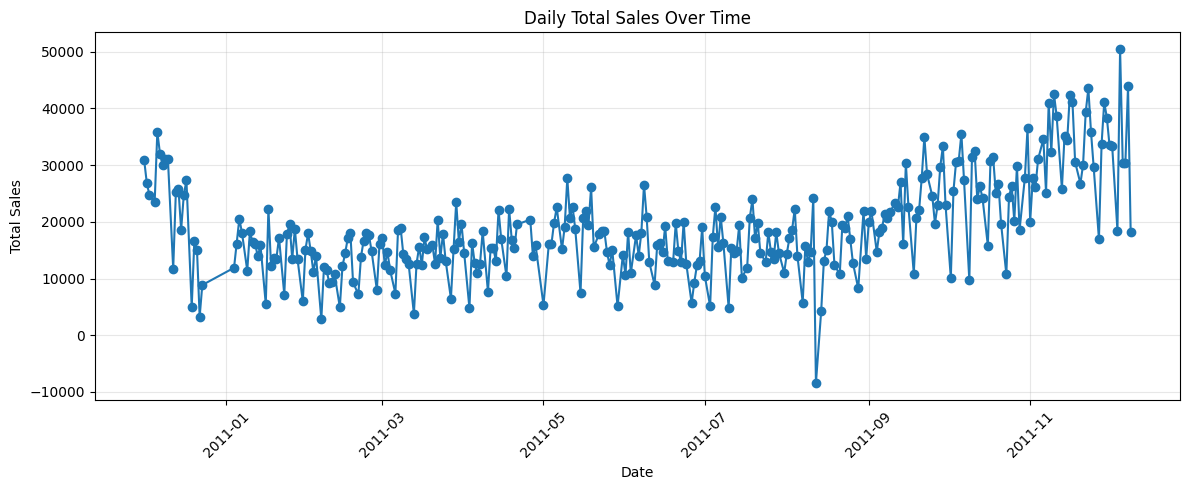

In [125]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Daily Total Sales Over Time")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

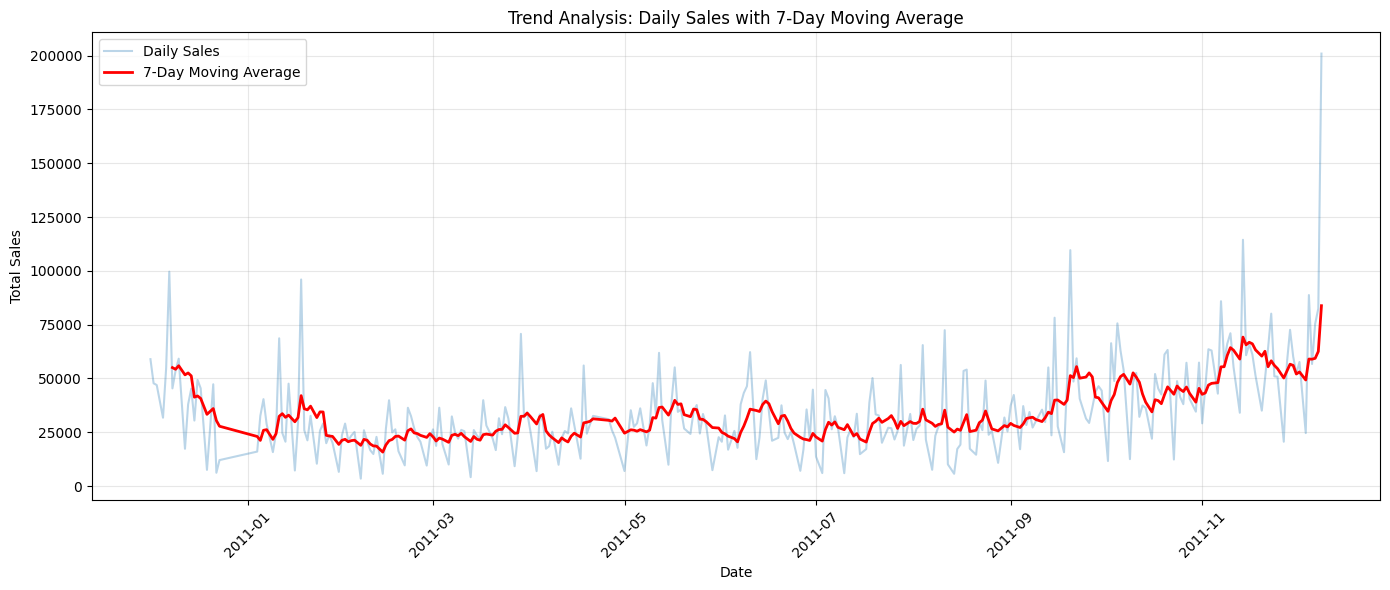

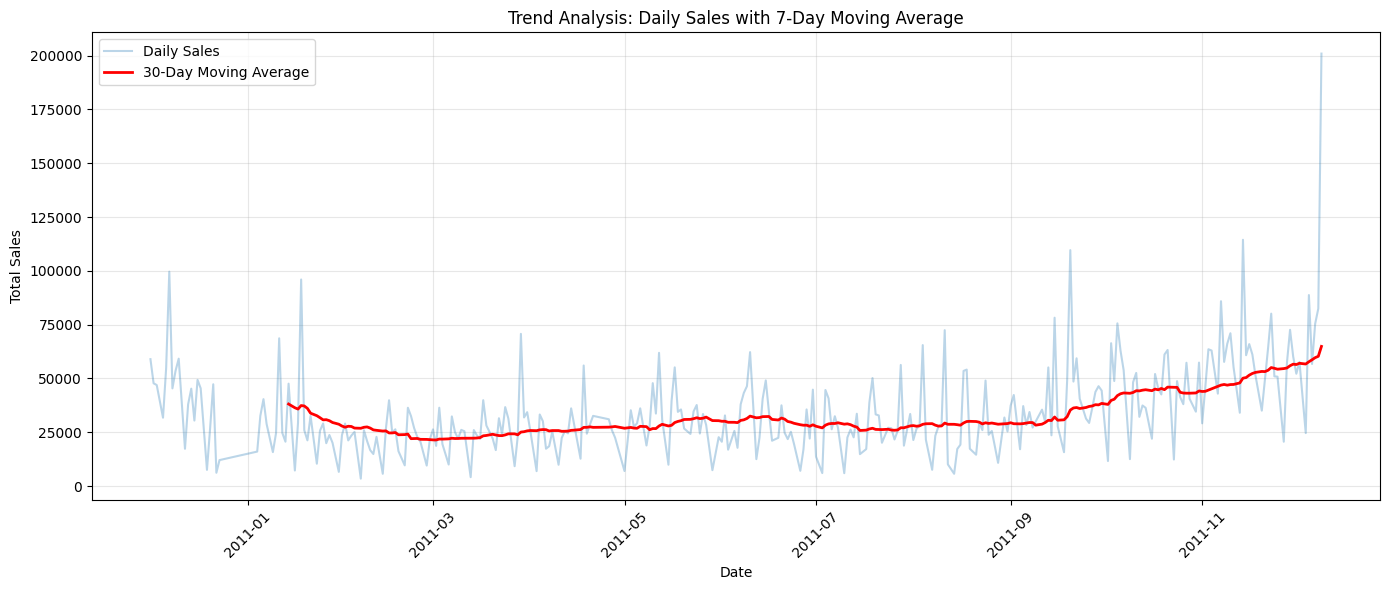

In [19]:
daily_sales["RollingMean_7"] = daily_sales["TotalAmount"].rolling(window=7).mean()

plt.figure(figsize=(14,6))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], alpha=0.3, label="Daily Sales")  # raw daily sales
plt.plot(daily_sales["Date"], daily_sales["RollingMean_7"], color='red', linewidth=2, label="7-Day Moving Average")  # trend

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis: Daily Sales with 7-Day Moving Average")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

daily_sales["RollingMean_30"] = daily_sales["TotalAmount"].rolling(window=30).mean()

plt.figure(figsize=(14,6))
plt.plot(daily_sales["Date"], daily_sales["TotalAmount"], alpha=0.3, label="Daily Sales")  # raw daily sales
plt.plot(daily_sales["Date"], daily_sales["RollingMean_30"], color='red', linewidth=2, label="30-Day Moving Average")  # trend

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Trend Analysis: Daily Sales with 7-Day Moving Average")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Association Rule Mining  

In [20]:
transactions = baskets["Description"].apply(
    lambda basket: [str(item) for item in basket]
).tolist()
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)
df_hot = pd.DataFrame(te_array, columns=te.columns_)
df_hot

,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20605,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20606,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20607,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20608,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [83]:
frequent_items = apriori(df_hot, min_support=0.03, use_colnames=True)
frequent_items = frequent_items.sort_values("support", ascending=False)
frequent_items

,support,itemsets
114,0.109656,(WHITE HANGING HEART T-LIGHT HOLDER)
46,0.101504,(JUMBO BAG RED RETROSPOT)
91,0.096507,(REGENCY CAKESTAND 3 TIER)
77,0.081805,(PARTY BUNTING)
63,0.075885,(LUNCH BAG RED RETROSPOT)
...,...,...
56,0.030519,(LOVE BUILDING BLOCK WORD)
104,0.030519,(SET OF 60 PANTRY DESIGN CAKE CASES )
107,0.030519,(SMALL WHITE HEART OF WICKER)
92,0.030228,(RETROSPOT HEART HOT WATER BOTTLE)


support:
0.1  --> 2 rows
0.09 --> 3 rows
0.08 --> 4 rows
0.07 --> 6 rows
0.06 --> 10 rows
0.05 --> 31 rows
0.04 --> 64 rows
0.03 --> 126 rows*
0.02 --> 352 rows
0.01 --> 305371 rows
I decided to keep the support of 0.03 because it was the largest support in which there were rules with lifts larger than 1; I tried with larger supports, however, non of them had a lift larger than 1 meaning they were frequent but not strong like they were purchased a lot together but more separatly.
0.06, 0.05 --> no lift larger than 1
0.04 --> 2 ones with lift larger than 1

In [85]:
rules = association_rules(frequent_items, metric="lift", min_threshold=2)
rules = rules.sort_values("lift", ascending=False)
rules["lift"]
len(rules)

14

lift:
20 --> 0
15 --> 2
10 --> 6
2 --> 14*
1.1 --> 14

In [87]:
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)
rules = rules.sort_values("confidence", ascending=False)
rules["confidence"]
len(rules)



10

confidence:
0.01 14
0.1 14
0.2
0.3
0.4 11
0.5 10*
0.6 8
0.7 3
0.8 1
0.9 1
considering that the lift and support thresholds are already picked, I chose the largest confidence that provided me with at least 10 rules. Therefore I will have 10 strongest rules.

In [88]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.037166,0.049248,0.030713,0.826371,16.779804,1.0,0.028883,5.475760,0.976705,0.551394,0.817377,0.725008
1,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.049248,0.051722,0.037263,0.756650,14.629045,1.0,0.034716,3.896768,0.979901,0.584920,0.743377,0.738550
2,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.051722,0.049248,0.037263,0.720450,14.629045,1.0,0.034716,3.401012,0.982458,0.584920,0.705970,0.738550
0,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.059098,0.101504,0.040029,0.677340,6.673028,1.0,0.034030,2.784651,0.903540,0.331992,0.640889,0.535850
7,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.047550,0.050995,0.031053,0.653061,12.806462,1.0,0.028628,2.735368,0.967940,0.460101,0.634419,0.631003


In [91]:
filtered_rules = rules[
    (rules["lift"] > 2) &
    (rules["support"] > 0.03) &
    (rules["confidence"] >= 0.5)
]

filtered_rules = filtered_rules.sort_values("lift", ascending=False)
print(len(filtered_rules))
top10_rules = filtered_rules.head(10)
top10_rules

10


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.037166,0.049248,0.030713,0.826371,16.779804,1.0,0.028883,5.475760,0.976705,0.551394,0.817377,0.725008
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.049248,0.037166,0.030713,0.623645,16.779804,1.0,0.028883,2.558314,0.989116,0.551394,0.609118,0.725008
1,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.049248,0.051722,0.037263,0.756650,14.629045,1.0,0.034716,3.896768,0.979901,0.584920,0.743377,0.738550
2,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.051722,0.049248,0.037263,0.720450,14.629045,1.0,0.034716,3.401012,0.982458,0.584920,0.705970,0.738550
6,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.050995,0.047550,0.031053,0.608944,12.806462,1.0,0.028628,2.435585,0.971453,0.460101,0.589421,0.631003
7,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.047550,0.050995,0.031053,0.653061,12.806462,1.0,0.028628,2.735368,0.967940,0.460101,0.634419,0.631003
0,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.059098,0.101504,0.040029,0.677340,6.673028,1.0,0.034030,2.784651,0.903540,0.331992,0.640889,0.535850
5,(LUNCH BAG BLACK SKULL.),(LUNCH BAG RED RETROSPOT),0.061766,0.075885,0.031101,0.503535,6.635457,1.0,0.026414,1.861389,0.905206,0.291894,0.462767,0.456691
3,(JUMBO STORAGE BAG SUKI),(JUMBO BAG RED RETROSPOT),0.057448,0.101504,0.035129,0.611486,6.024253,1.0,0.029297,2.312650,0.884836,0.283699,0.567596,0.478783
4,(JUMBO SHOPPER VINTAGE RED PAISLEY),(JUMBO BAG RED RETROSPOT),0.057011,0.101504,0.032994,0.578723,5.701477,1.0,0.027207,2.132793,0.874461,0.262853,0.531131,0.451886


In [92]:
top10_rules[[
    "antecedents", 
    "consequents", 
    "support", 
    "confidence", 
    "lift"
]]

,antecedents,consequents,support,confidence,lift
9,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030713,0.826371,16.779804
8,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.030713,0.623645,16.779804
1,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.037263,0.756650,14.629045
2,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.037263,0.720450,14.629045
6,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.031053,0.608944,12.806462
7,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.031053,0.653061,12.806462
0,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.040029,0.677340,6.673028
5,(LUNCH BAG BLACK SKULL.),(LUNCH BAG RED RETROSPOT),0.031101,0.503535,6.635457
3,(JUMBO STORAGE BAG SUKI),(JUMBO BAG RED RETROSPOT),0.035129,0.611486,6.024253
4,(JUMBO SHOPPER VINTAGE RED PAISLEY),(JUMBO BAG RED RETROSPOT),0.032994,0.578723,5.701477


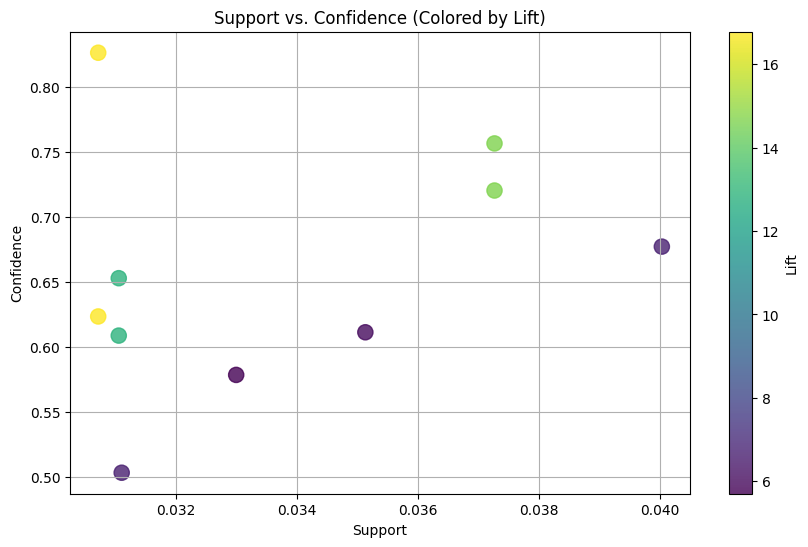

In [93]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    top10_rules["support"],
    top10_rules["confidence"],
    c=top10_rules["lift"],
    s=120,                
    alpha=0.8,            
)

plt.colorbar(scatter, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs. Confidence (Colored by Lift)")
plt.grid(True)

plt.show()

The biggest business value is brought by the most interesting rules meaning the ones with highest lift
After filtering the lift, the confidence is prioritized meaning how likeble it is for the item Y to be purchased if item X is purchased
And after that the support is prioritized meaning how big the opportunity is 
so I chose this formula to assign some weight to each of the factors in the right order:
top10_rules["biz_score"] = (
    top10_rules["lift"] * 0.5 +
    top10_rules["confidence"] * 0.3 +
    top10_rules["support"] * 0.2
)

C:\Users\RayanTech\AppData\Local\Temp\ipykernel_4120\3484057851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10_rules["biz_score"] = (


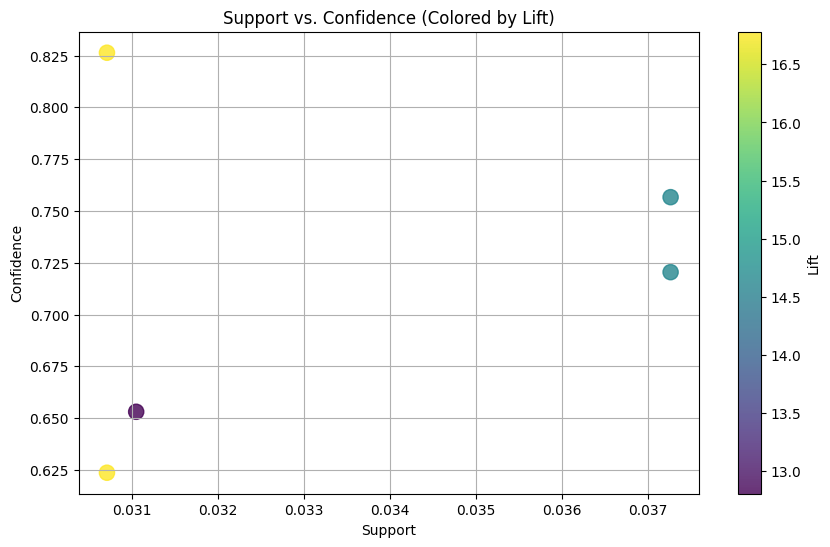

In [95]:
top10_rules["biz_score"] = (
    top10_rules["lift"] * 0.5 +
    top10_rules["confidence"] * 0.3 +
    top10_rules["support"] * 0.2
)

best5 = top10_rules.sort_values("biz_score", ascending=False).head(5)
best5

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    best5["support"],
    best5["confidence"],
    c=best5["lift"],
    s=120,                
    alpha=0.8,            
)

plt.colorbar(scatter, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs. Confidence (Colored by Lift)")
plt.grid(True)

plt.show()

1. Bundle Promotions (Cross-sell bundles)

Rules with high confidence + high lift identify products that customers consistently buy together.

How to use the rules:

Create special bundles (e.g., “Buy X, get Y at 20% off”).

Offer automated recommendations on checkout pages (“Customers who bought X also bought Y”).

Use email campaigns: “You purchased X — here’s a discount on Y.”

Business impact:

Increases average order value (AOV).

Improves conversion rate through targeted suggestions.

2. Store/Product Placement

Rules with good support + high lift show which items should be located close to each other.

How to use the rules:

Place items that frequently co-occur in the same aisle or shelf.

In e-commerce, place them in “Recommended for you” or “Frequently bought together” sections.

Use them to optimize warehouse picking routes to reduce picking time.

Business impact:

Reduces shopping friction.

Increases impulse purchases.

Improves online recommendation accuracy.

3. Targeted Marketing Campaigns

Rules with high lift but lower support reveal small-but-valuable niche customer patterns.

How to use the rules:

Segment customers based on their previous purchases.

Send personalized offers:
“Since you bought X, here’s 10% off Y — customers like you often buy both.”

Optimize remarketing ads for products that frequently co-occur.

Business impact:

Raises ROI of ads and email campaigns.

Improves customer retention through personalization.

Part 2: Time Series Forecasting 

c:\Users\RayanTech\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\RayanTech\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\RayanTech\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


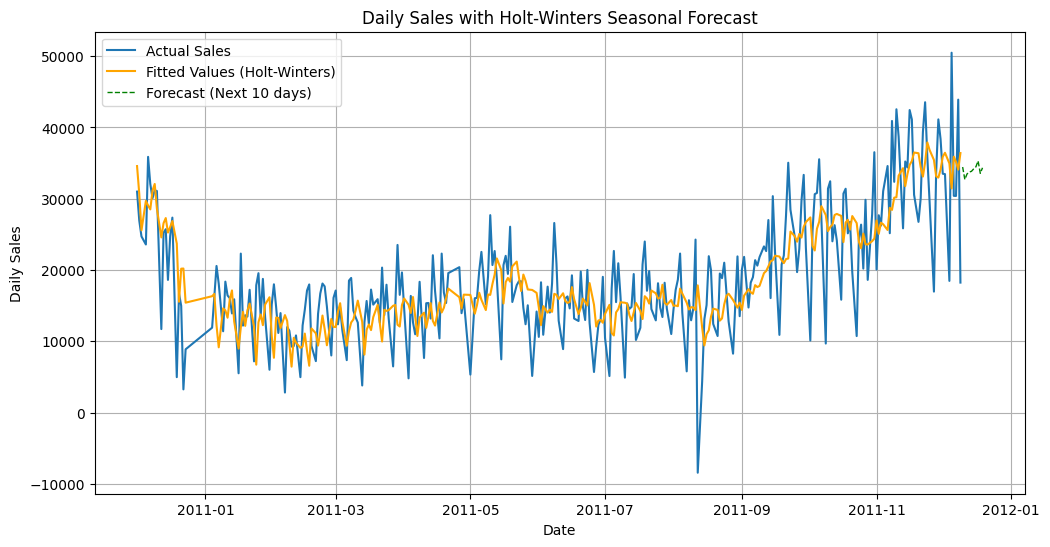

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])
ts = daily_sales.set_index("Date")["TotalAmount"]

model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="add",
    seasonal_periods=7  # weekly seasonality
).fit(optimized=True)

forecast_days = 10
forecast = model.forecast(forecast_days)
forecast_dates = pd.date_range(start=ts.index[-1] + pd.Timedelta(days=1), periods=forecast_days)

plt.figure(figsize=(12,6))
plt.plot(ts, label="Actual Sales")
plt.plot(ts.index, model.fittedvalues, label="Fitted Values (Holt-Winters)", color="orange", linewidth=1.5)
plt.plot(forecast_dates, forecast, label="Forecast (Next 10 days)", linestyle='--', color='green', linewidth=1)
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Daily Sales with Holt-Winters Seasonal Forecast")
plt.legend()
plt.grid(True)
plt.show()
